In [1]:
import h5py 
import numpy as np
import matplotlib.pyplot as plt

hdf = h5py.File('data1.h5', 'r') 
ls = list(hdf.keys())
print(ls) #print the keys 
dataset = np.array(hdf['data'])
print(dataset.shape) #Print the dimension of the 'data'
# (np.min(dataset), np.max(dataset))

['data', 'invXForm', 'xForm']
(10240, 3, 16, 16)


In [ ]:
#Displaying 200 random sample patches in RGB format
for i in range(200):
    j  = np.random.randint(0,dataset.shape[0])
    plt.subplot(10,20,i+1)
    plt.imshow(dataset[j].T)
    plt.axis('off')   

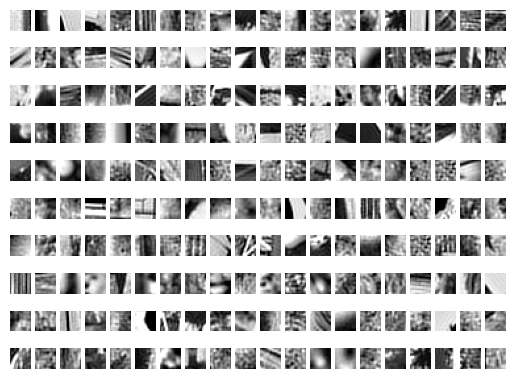

In [3]:
#Obtaining the R, B and G channels
R,G,B = dataset[:,0],dataset[:,1],dataset[:,2]
#converting images to grayscale
grayscale_data = 0.2126*R + 0.7152*G + 0.0722*B

#Removing the mean pixel intensity of each image from itself
num_images = grayscale_data.shape[0]
for i in range(num_images):
    grayscale_data[i] = grayscale_data[i] - np.mean(grayscale_data[i])

#Clipping the data range at +/-3 std
grayscale_data = np.clip(grayscale_data, -3*np.std(grayscale_data),3*np.std(grayscale_data))

#Mapping the +/-3 std data range to [0.1 0.9] 
grayscale_data  = np.interp(grayscale_data, (np.min(grayscale_data), np.max(grayscale_data)), (0.1,0.9))

#Displaying 200 random sample patches in gray format
for i in range(200):
    j  = np.random.randint(0,grayscale_data.shape[0])
    plt.subplot(10,20,i+1)
    plt.imshow(grayscale_data[j], cmap='gray')
    plt.axis('off')   


In [4]:
#Flattening the grayscale data for the autoencoder
grayscale_data_flattened = np.reshape(grayscale_data, (grayscale_data.shape[0],256))


In [5]:

class Autoencoder:
    def __init__(self,data,batch_size,no_hidden_units,learning_rate,lambbda,beta,rho):
        self.training_data = data.T
        self.batch_size = batch_size
        self.no_hidden_units = no_hidden_units
        self.learning_rate = learning_rate

        #Tykhonov regularization lambda
        self.lambbda = lambbda

        #Kullback-Leibler diverg. rho,beta
        self.beta = beta
        self.rho = rho
        self.rho_avg = None
        
        #empty lists to save losses and mse
        self.avg_batch_cost =[]
        self.loss_cost = []
        self.mse = []

        #hidden layer output
        self.A1 = None 
        # weighted sum of the output
        self.Zbc= None
        # output of the output layer
        self.A2 = None 
        self.output = None
        
        


    # weights initialization
        Wo =np.sqrt(6/(256 + no_hidden_units +1))
        self.Wab = np.random.uniform(-Wo,Wo, size =(257 , no_hidden_units ))
        self.Wbc = np.random.uniform(-Wo,Wo, size =(no_hidden_units +1 ,256))


    def sigmoid(self,x):
        return 1 / (1 + np.exp(-x))
        
    def sigmoid_derivative(self, z):
        return (self.sigmoid(z)*(1 - self.sigmoid(z)))
    
    def forward_prop(self, batch):
        self.Zab = np.dot(self.Wab.T,np.append(np.ones((1 ,len(batch[0]))), batch ,axis =0))
        
        self.A1 = self.sigmoid(self.Zab)
     
        self.Zbc = self.Wbc.T@np.append(np.ones((1 , len(batch[0]))) , self.A1, axis=0)

        self.o= self.sigmoid(self.Zbc)
        self.output = self.o

    def backward_prop(self, batch):
       
        dZ = self.output - batch 
        #derivative of the squared error with respect to Zbc
        dZbc = dZ*self.sigmoid(self.Zbc)*(1-self.sigmoid(self.Zbc)) 
        
        ##derivative of the squared error with respect to Wbc
        dWbc = np.transpose(np.matmul(dZbc, np.transpose(np.append(np.ones((1 ,len(batch[0]))), self.A1, axis=0 ))))
                                                                                      
        temp_hat = (self.Wbc[1:] @ dZ)/ len(batch) + self.beta*(-self.rho/self.rho_avg + (1-self.rho)/(1 - self.rho_avg)).reshape(self.no_hidden_units,1)
        temp = temp_hat*self.sigmoid_derivative(self.Zab)

        #derivative of the squared error with respect to Wab
        dWab = np.append(np.ones((1 , len(batch[0]))) , batch , axis =0) @temp.T

        #derivative of the cost function with respect to Wab and Wbc
        dWbc = dWbc + self.lambbda * np.append(np.zeros((1 ,256)), self.Wbc [1:], axis=0)
        dWab = dWab + self.lambbda * np.append(np.zeros((1 , self.no_hidden_units )), self.Wab[1:], axis=0 )
                                                             
        return dWab, dWbc

    def aeCost(self , batch):
        self.forward_prop(batch)
        #mse cost
        mse_cost = sum(sum((self.output- batch)**2))/(2*self.batch_size)
        #Tykhonov reg cost
        t_cost = (self.lambbda*(sum(sum(self.Wab**2))+ sum(sum(self.Wbc**2)))) / 2
        #KL cost
        self.rho_avg = np.sum(self.A1 ,axis =1)/len(self.A1[0])
        kl_cost = self.beta*sum(self.rho*np.log(self.rho/self.rho_avg) + (1 - self.rho )*np.log((1-self.rho)/(1-self.rho_avg)))
        
        cost = mse_cost + t_cost + kl_cost

        dWab , dWbc= self.backward_prop(batch)
        return cost , dWab , dWbc

    def update_parameters(self):
        total_cost = 0
        self.avg =[]
        for i in range (len(self.training_data[0])// self.batch_size):
            batch_cost , dWab , dWbc = self.aeCost(self.training_data[:,i*self.batch_size:(i+1)*self.batch_size])

            #parameters update
            self.Wbc = self.Wbc - self.learning_rate*dWbc
            self.Wab = self.Wab - self.learning_rate*dWab
            self.avg.append(batch_cost)

    def model_train(self, max_epoch):
        for i in range (max_epoch):
            print(i)
            self.forward_prop(self.training_data)
            self.mse.append(sum(sum((self.output- self.training_data)**2))/(2*len(self.training_data[0])))
            self.update_parameters()
            self.avg_batch_cost.append(np.sum(self.avg)*(self.batch_size / 10240))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
0.3240647972588344


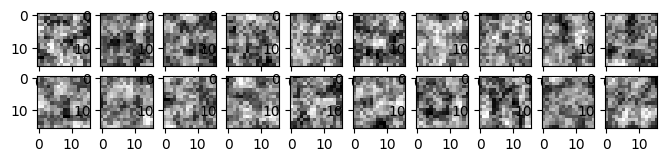

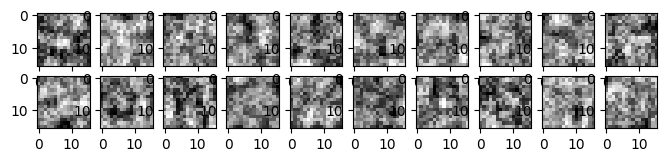

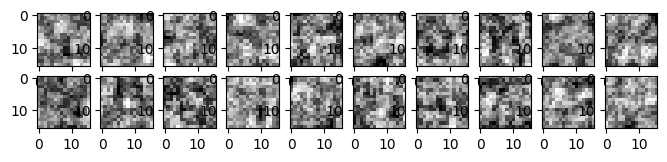

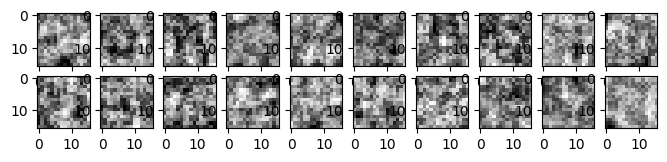

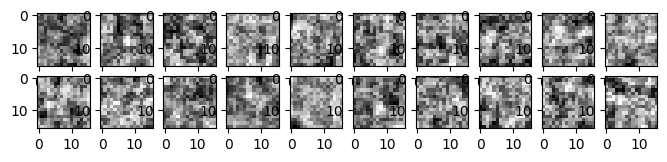

Text(0.5, 0, 'number of epochs')

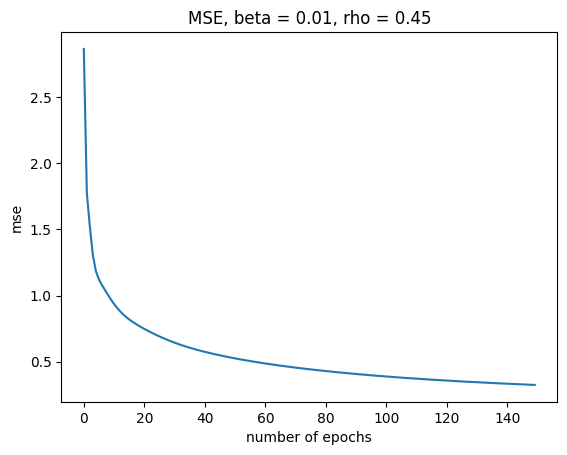

In [6]:
model = Autoencoder(grayscale_data_flattened,16,64,0.01,5*10**-4,0.01,0.45)
model.model_train(150)
mse = model.mse
print(mse[149])
W = model.Wab[1:]
c = 10  #columns number
r = 10 #rowss number
for j in range (5):
    fig = plt.figure(figsize =(8,8))
    for i in range (1, 21):
        fig.add_subplot (r,c , i +20*j)
        plt.imshow(W[:,i +5*j -1].reshape(16 ,16) , cmap ='gray')
    plt.show ()

plt.title('MSE, beta = 0.01, rho = 0.45')
plt.plot(mse) 
plt.ylabel('mse')
plt.xlabel('number of epochs')

In [13]:
import sys


import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd





question = sys.argv[1]

def miniproject(question):
    if question == '1' :
        print("Question:", question)
        hdf = h5py.File('data1.h5', 'r') 
        ls = list(hdf.keys())
        print(ls) #print the keys 
        dataset = np.array(hdf['data'])
        print(dataset.shape) #Print the dimension of the 'data'
        # (np.min(dataset), np.max(dataset))

        #Displaying 200 random sample patches in RGB format
        for i in range(200):
            j  = np.random.randint(0,dataset.shape[0])
            plt.subplot(10,20,i+1)
            plt.imshow(dataset[j].T)
            plt.axis('off')   

        #Obtaining the R, B and G channels
        R,G,B = dataset[:,0],dataset[:,1],dataset[:,2]
        #converting images to grayscale
        grayscale_data = 0.2126*R + 0.7152*G + 0.0722*B

        #Removing the mean pixel intensity of each image from itself
        num_images = grayscale_data.shape[0]
        for i in range(num_images):
            grayscale_data[i] = grayscale_data[i] - np.mean(grayscale_data[i])

        #Clipping the data range at +/-3 std
        std =np.std(grayscale_data)
        grayscale_data = np.clip(grayscale_data, -3*std,3*std)

        #Mapping the +/-3 std data range to [0.1 0.9] 
        grayscale_data  = np.interp(grayscale_data, (np.min(grayscale_data), np.max(grayscale_data)), (0.1,0.9))

        #Displaying 200 random sample patches in gray format
        for i in range(200):
            j  = np.random.randint(0,grayscale_data.shape[0])
            plt.subplot(10,20,i+1)
            plt.imshow(grayscale_data[j], cmap='gray')
            plt.axis('off')   

        #Flattening the grayscale data for the autoencoder
        grayscale_data_flattened = np.reshape(grayscale_data, (grayscale_data.shape[0],256))

        class Autoencoder:
            def __init__ (self,data,batch_size,no_hidden_units,learning_rate,lambbda, beta,rho ):
                self.training_data = data.T
                self.batch_size = batch_size
                self.no_hidden_units = no_hidden_units
                self.learning_rate = learning_rate

                #Tykhonov regularization lambda
                self.lambbda = lambbda

                #Kullback-Leibler diverg. rho,beta
                self.beta = beta
                self.rho = rho
                self.rho_avg = None
                
                #empty lists to save losses and mse
                self.avg_batch_cost =[]
                self.loss_cost = []
                self.mse = []

                #hidden layer output
                self.A1 = None 
                # weighted sum of the output
                self.output = None
                self.A2 = None 
                self.Zbc= None
                # output of the output layer
            
            
                
                


            # weights initialization
                Wo =np.sqrt(6/(256+no_hidden_units+1))
                self.Wab = np.random.uniform(-Wo,Wo, size =(257,no_hidden_units))
                self.Wbc = np.random.uniform(-Wo,Wo, size =(no_hidden_units +1 ,256))


            def sigmoid(self,x):
                clipped_x = np.clip(x, -50, 50)
                return 1 / (1 + np.exp(-clipped_x))
                
            def sigmoid_derivative(self, A2):
                return (self.sigmoid( self.A2 )*(1 - self.sigmoid(self.A2)))
            
            def forward_prop(self, batch):
                Zab = np.dot(self.Wab.T, np.append(np.ones((1 ,len(batch[0]))), batch,axis =0))
                
                self.A1 = self.sigmoid(Zab)
            
                self.Zbc = self.Wbc.T@np.append(np.ones((1 , len(batch[0]))) , self.A1, axis=0)

                self.o= self.sigmoid(self.Zbc)
                self.output = self.o

            def backward_prop(self, batch):
            
                dZ = self.output - batch #derivative of the squared error

                #derivative of the squared error with respect to Zbc
                dZbc = dZ*self.sigmoid(self.Zbc)*(1-self.sigmoid(self.Zbc)) 
                
                ##derivative of the squared error with respect to Wbc
                dWbc = np.transpose(np.matmul(dZbc, np.transpose(np.append(np.ones((1 ,len(batch[0]))), self.A1, axis=0 ))))
                                                                                            
                temp_hat = (self.Wbc[1:] @ dZ)/ len(batch) + self.beta*(-self.rho/self.rho_avg + (1-self.rho)/(1 - self.rho_avg)).reshape(self.no_hidden_units,1)
                temp = temp_hat*self.A1*(1-self.A1)

                #derivative of the squared error with respect to Wab
                dWab = np.append(np.ones((1 , len(batch[0]))) , batch , axis =0) @temp.T

                #derivative of the cost function with respect to Wab and Wbc
                dWbc = dWbc + self.lambbda * np.append(np.zeros((1 ,256)), self.Wbc [1:], axis=0)
                dWab = dWab + self.lambbda * np.append(np.zeros((1 , self.no_hidden_units)), self.Wab[1:], axis=0 )
                                                                    
                return dWab, dWbc

            def aeCost(self , batch):
                self.forward_prop(batch)
                #mse cost
                mse_cost = sum(sum((self.output- batch)**2))/(2*self.batch_size)
                #Tykhonov reg cost
                t_cost = (self.lambbda*(sum(sum(self.Wab**2))+ sum(sum(self.Wbc**2)))) / 2
                #KL cost
                self.rho_avg = np.sum(self.A1 ,axis =1)/len(self.A1[0])
                kl_cost = self.beta*sum(self.rho*np.log(self.rho/self.rho_avg) + (1 - self.rho )*np.log((1-self.rho)/(1-self.rho_avg)))
                
                cost = mse_cost + t_cost + kl_cost

                dWab , dWbc = self.backward_prop(batch)
                return cost , dWab , dWbc

            def update_parameters(self):
                total_cost = 0
                self.avg =[]
                for i in range (len(self.training_data[0])// self.batch_size):
                    batch_cost , dWab , dWbc = self.aeCost(self.training_data[:,i*self.batch_size:(i+1)*self.batch_size])

                    #parameters update
                    self.Wbc = self.Wbc - self.learning_rate*dWbc
                    self.Wab = self.Wab - self.learning_rate*dWab
                    self.avg.append(batch_cost)

            def model_train(self, max_epoch):
                for i in range (max_epoch):
                    print(i)
                    self.forward_prop(self.training_data)
                    self.mse.append(sum(sum((self.output- self.training_data)**2))/(2*len(self.training_data[0])))
                    self.update_parameters()
                    self.avg_batch_cost.append(np.sum(self.avg)*(self.batch_size / 10240))

        model = Autoencoder(grayscale_data_flattened,16,64,0.01,5*10**(-4),0.01,0.45)
        model.model_train(210)
        mse = model.mse
        print(mse[219])
        W = model.Wab[1:]
        c = 10  #columns number
        r = 10 #rowss number
        for j in range (5):
            fig = plt.figure(figsize =(8,8))
            for i in range (1, 21):
                fig.add_subplot (r,c , i +20*j)
                plt.imshow(W[:,i +5*j -1].reshape(16 ,16) , cmap ='gray')
            plt.show ()

        plt.title('MSE, beta = 0.01, rho = 0.45')
        plt.plot(mse) 
        plt.ylabel('mse')
        plt.xlabel('number of epochs')


    elif question == '2' :
        print("Question:", question)
        #Loading the input data
        hdf = h5py.File('data2.h5', 'r') 
        ls = list(hdf.keys())
        print(ls)
        X_train = np.array(hdf['trainx'])
        Y_train = np.array(hdf['traind'])
        X_test  = np.array(hdf['testx'])
        Y_test   = np.array(hdf['testd'])
        X_val  = np.array(hdf['valx'])
        Y_val  = np.array(hdf['vald'])
        words = np.array(hdf['words'])
        hdf.close()

        vocab_size = 250
        X_train =  X_train - 1
        Y_train =  Y_train - 1
        X_test  =  X_test - 1
        Y_test  =  Y_test -1
        X_val   =  X_val - 1
        Y_val   =  Y_val -1

        def one_hot_x(X, vocab_size):
            output = np.zeros((X.shape[0], X.shape[1], vocab_size))
            for i in range(X.shape[0]):
                for j in range(X.shape[1]):
                    index = X[i,j] 
                    output[i,j,index] = 1
            return output

        def one_hot_y(Y, vocab_size):
            output = np.zeros((Y.shape[0], vocab_size))
            for i in range(Y.shape[0]):
                    index = Y[i]
                    output[i,index] = 1
            return output
        
        X_train_onehot = one_hot_x(X_train,vocab_size)
        Y_train_onehot = one_hot_y(Y_train,vocab_size)
        X_test_onehot  = one_hot_x(X_test,vocab_size)
        Y_test_onehot   =one_hot_y(X_test,vocab_size)
        X_val_onehot  = one_hot_x(X_val,vocab_size)
        Y_val_onehot  = one_hot_y(X_val,vocab_size)
        
        #parameters
        vocab_size = 250
        word_embeddings_size = [32,16,8]
        hidden_sizes = [256, 128, 64]
        learning_rate = 0.15
        momentum_rate= 0.85
        max_epochs = 50

        i = 0 #to be varied
        embedding_size =  word_embeddings_size[i]
        hidden_size = hidden_sizes[i]
        mini_batch_size  = 200

        # Initialize weights and biases
        def parameters_initialization(vocab_size,embedding_size,hidden_size):
            EW = np.random.normal(0,0.01,(vocab_size, embedding_size)) #embeddings weights
            W1 = np.random.normal(0,0.01,(embedding_size*3, hidden_size))#hidden weights
            W2 = np.random.normal(0,0.01,(hidden_size, vocab_size)) #output weights
            b1 = np.zeros((1, hidden_size)) #hidden bias
            b2 = np.zeros((1, vocab_size))#output bias

            return {'EW':EW, 'W1':W1, 'W2':W2 , 'b1':b1, 'b2':b2}

        def velocity_initialization(parameters):
            Vds = {key: 0 for key in parameters.keys()}
            return Vds
        

        #Activation functions
        def sigmoid(z):
            return 1/(1+np.exp(-z))

        def softmax(a):
            a_scores = np.exp(a)
            return a_scores/np.sum(a_scores, axis=1, keepdims=True)

        #derivatives of activations

        def sigmoid_derivative(z):
            return sigmoid(z)*(1-sigmoid(z))
        

        def forward_prop(X_batch,parameters):
        #forward propagation
            embeddings_weights = parameters['EW']
            hidden_weights =  parameters['W1']
            output_weights =  parameters['W2']
            hidden_bias =  parameters['b1']
            output_bias = parameters['b2']

            E = np.dot(X_batch,embeddings_weights)
            E  = E.reshape((len(X_batch), -1))
            embedding_matrix  = E
            #hidden
            Z1 = np.dot(E,hidden_weights) + hidden_bias
            A1 = sigmoid(Z1)
            #output
            Z2 = np.dot(A1,output_weights)+output_bias
            A2 = softmax(Z2)

            cache = {'embedding_matrix': embedding_matrix, 'Z1': Z1, 'A1':A1, 'Z2':Z2, 'A2': A2}
            return A2, cache
    
        def crossentropycost(Y_pred, Y_batch):
                cost = -np.sum(Y_batch*np.log(Y_pred),axis=1)
                return np.mean(cost)

        def back_prop(X_batch, Y_batch,Y_predictions,cache, parameters):
                
                embedding_matrix = cache['embedding_matrix']
                A1 = cache['A1']
                Z1 = cache['Z1']

                W2 = parameters['W2']
                W1 = parameters['W1']

                dZ2 = Y_predictions - Y_batch
                dW2 = np.dot(A1.T,dZ2)/Y_batch.shape[0]
                db2 = np.sum(dZ2, axis = 0, keepdims= True)/Y_batch.shape[0]

                dZ1  = np.dot(dZ2, W2.T)*sigmoid_derivative(Z1)
                dW1 =  np.dot(embedding_matrix.T,dZ1)/Y_batch.shape[0]
                db1 =  np.sum(dZ1, axis = 0, keepdims= True)/Y_batch.shape[0]


                dE =  np.dot(dZ1, W1.T)
                dE = np.reshape(dE, (Y_batch.shape[0], 3,embedding_size))
            
                temp = 0
                for i in range(3):
                        x_ind = X_batch[:, i]
                        temp  += np.dot(x_ind.T, dE[:,i])
                temp = temp/3
                dEW  = temp/Y_batch.shape[0]
                

                grads = {'dEW':dEW, 'dW1':dW1, 'dW2':dW2 , 'db1':db1, 'db2':db2}
                return grads


        def update_parameters(parameters, gradients, learning_rate, momentum_rate,Vds):
                for key in parameters.keys():
                        Vd = Vds[key]
                        gradient = gradients['d'+key]
                        Vds[key] = momentum_rate*Vd +(1-momentum_rate)*gradient
                        parameters[key] -= learning_rate*Vds[key]
                        # print(parameters['EW'])
                return parameters, Vds
        

        #Train Model
        def train_model(X_train_onehot,Y_train_onehot,learning_rate,momentum_rate, max_epochs,embedding_size,hidden_size):
                
            parameters = parameters_initialization(vocab_size,embedding_size,hidden_size)
            Vds = velocity_initialization(parameters)
                # EW = parameters['EW']
                # W1 =  parameters['W1']
                # W2 =  parameters['W2']
                # b1 =  parameters['b1']
                # b2 = parameters['b2']
            cost_list = []
            val_cost_list = []
            for epoch in range(max_epochs):
                # print(f"Epoch = {epoch}")
                print(epoch)
                #shuffle data for SGD
                indices = np.random.permutation(X_train_onehot.shape[0])
                X_train_onehot_shuffled = X_train_onehot[indices]
                Y_train_onehot_shuffled = Y_train_onehot[indices]
                cost_batch = []
                for i in range(0,X_train_onehot.shape[0], mini_batch_size):
                    X_batch = X_train_onehot_shuffled[i:i+mini_batch_size]
                    Y_batch = Y_train_onehot_shuffled[i:i+mini_batch_size]
                    
                    # print(Vds['b2'])
                    A2, cache = forward_prop(X_batch,parameters)

                    cost = crossentropycost(A2, Y_batch)
                    cost_batch .append(cost)

                    grads = back_prop(X_batch, Y_batch,A2,cache, parameters)

                    parameters, Vds = update_parameters(parameters, grads, learning_rate, momentum_rate,Vds)
                    
                # print(f"Cost after {epoch}th epoch = {cost}")
                cost_list.append(np.mean(cost_batch))
                A2_val, cache_val = forward_prop(X_val_onehot,parameters)
                val_cost = crossentropycost(A2_val, Y_val_onehot)
                val_cost_list.append(val_cost)
            return (parameters,cost_list,val_cost_list)
        

        i = 0 # (D,P) = (32,256)
        embedding_size =  word_embeddings_size[i] # D =32
        hidden_size = hidden_sizes[i] #P = 256
        parameters,cost,val_cost = train_model(X_train_onehot,Y_train_onehot,learning_rate,momentum_rate, max_epochs,embedding_size,hidden_size)
        # plt.plot(range(10),val_cost[:10])
        # plt.plot(range(50),np.array(cost))

        plt.title('(D,P) = (32,256)')
        plt.plot(range(50),np.array(cost),label='Training')
        plt.xlabel('number of epochs')
        plt.ylabel('cost')
        plt.legend()

        #4th word prediction
        model1  ={}
        for _ in range(5):
            number = np.random.randint(1,X_test.shape[0])
            Sentence = (words[X_test[number][0]].decode('UTF-8') +" "+ 
                        words[X_test[number][1]].decode('UTF-8') + " "+ 
                        words[X_test[number][2]].decode('UTF-8') + " "+ "'"+
                        words[Y_test[number]].decode('UTF-8')+"'" )
            A2, cache = forward_prop(X_test_onehot[number].reshape((1, 3, 250)),parameters)
            result = tuple((x.decode('UTF-8'), list(y*100)) for x, y in zip(tuple(words), tuple(A2.T)))
            a = sorted(result, key= lambda result : result[1], reverse=True)
            for_append = []
            for i in range(10):
                for_append.append(a[i])
            model1[Sentence] = for_append

        pd.DataFrame(model1)


        i = 1 #(D,P) = (16,128)
        embedding_size =  word_embeddings_size[i] # D =16
        hidden_size = hidden_sizes[i] #P = 128
        parameters1,cost1,val_cost1 = train_model(X_train_onehot,Y_train_onehot,learning_rate,momentum_rate, max_epochs,embedding_size,hidden_size)
        # plt.plot(range(10),val_cost[:10])
        # plt.plot(range(50),np.array(cost))

        plt.title('(D,P) = (16,128)')
        plt.plot(range(50),np.array(cost1),label='Training')
        plt.xlabel('number of epochs')
        plt.ylabel('cost')
        plt.legend()

        #4th word prediction
        model2  ={}
        for _ in range(5):
            number = np.random.randint(1,X_test.shape[0])
            Sentence = (words[X_test[number][0]].decode('UTF-8') +" "+ 
                        words[X_test[number][1]].decode('UTF-8') + " "+ 
                        words[X_test[number][2]].decode('UTF-8') + " "+ "'"+
                        words[Y_test[number]].decode('UTF-8')+"'" )
            A2, cache = forward_prop(X_test_onehot[number].reshape((1, 3, 250)),parameters1)
            result = tuple((x.decode('UTF-8'), list(y*100)) for x, y in zip(tuple(words), tuple(A2.T)))
            a = sorted(result, key= lambda result : result[1], reverse=True)
            for_append = []
            for i in range(10):
                for_append.append(a[i])
            model2[Sentence] = for_append
        model2

        pd.DataFrame(model2)


        i = 2 #(D,P) = (8,64)
        embedding_size =  word_embeddings_size[i] # D =8
        hidden_size = hidden_sizes[i] #P = 64
        parameters2,cost2,val_cost2 = train_model(X_train_onehot,Y_train_onehot,learning_rate,momentum_rate, max_epochs,embedding_size,hidden_size)
        # plt.plot(range(10),val_cost[:10])
        # plt.plot(range(50),np.array(cost))

        plt.title('(D,P) = (8,64)')
        plt.plot(range(50),np.array(cost2),label='Training')
        plt.xlabel('number of epochs')
        plt.ylabel('cost')
        plt.legend()

        #4th word prediction
        model3  ={}
        for _ in range(5):
            number = np.random.randint(1,X_test.shape[0])
            Sentence = (words[X_test[number][0]].decode('UTF-8') +" "+ 
                        words[X_test[number][1]].decode('UTF-8') + " "+ 
                        words[X_test[number][2]].decode('UTF-8') + " "+"'"+
                        words[Y_test[number]].decode('UTF-8')+"'")
            A2, cache = forward_prop(X_test_onehot[number].reshape((1, 3, 250)),parameters2)
            result = tuple((x.decode('UTF-8'), list(y*100)) for x, y in zip(tuple(words), tuple(A2.T)))
            a = sorted(result, key= lambda result : result[1], reverse=True)
            for_append = []
            for i in range(10):
                for_append.append(a[i])
            model3[Sentence] = for_append
        model3
        pd.DataFrame(model3)



    elif question == '3' :
        print("Question:", question)
        #Loading the input data
        hdf = h5py.File('data3.h5', 'r') 
        print(list(hdf.keys()))
        trX = np.array(hdf['trX'])
        trY= np.array(hdf['trY'])
        tstX  = np.array(hdf['tstX'])
        tstY   = np.array(hdf['tstY'])
        hdf.close()

        #Hyperparamaters
        batch_size = 32 #Number of samples for the SGD
        learning_rate = 0.1
        hidden_units = 128 # Number of neurons in the RNN layer
        max_epochs = 50
        momentum_rate = 0.85
        
        #
        time_steps = trX.shape[1]
        n_classes = trY.shape[1]

        #Weights and biases initilization with Xavier uniform distribution
        def xavier_init(shape):
            return np.random.uniform(-np.sqrt(6.0/(shape[0]+shape[1])),np.sqrt(6.0/(shape[0]+shape[1])),shape)

        num_inputs = trX.shape[2]
        no_labels = trY.shape[1]
        def initiliaze_parameters(num_inputs,hidden_units):                         
            Wxh = xavier_init((num_inputs,hidden_units))
            Whh = xavier_init((hidden_units, hidden_units))
            Why = xavier_init((hidden_units, no_labels ))
            bh = np.zeros((1, hidden_units))
            by = np.zeros((1, no_labels ))

            return {'Wxh':Wxh,'Whh': Whh,'Why': Why,'bh': bh,'by': by}
        def velocity_initialization(parameters):
            Vds = {key: 0 for key in parameters.keys()}
            return Vds
        #Functions to be used in training the model
        def tanh(x):
            return np.tanh(x)

        def sigmoid(z):
            return 1/(1+np.exp(-z))

        def softmax(a):
            a_scores = np.exp(a)
            return a_scores/np.sum(a_scores, axis=1, keepdims=True)

        def rnn_forward(X_batch, h_prev,parameters): #

            Wxh = parameters['Wxh']
            Whh = parameters['Whh']
            Why = parameters['Why']
            bh = parameters['bh']
            by = parameters['by']

            #initiliaze the hidden states and output sequence
            h = np.zeros((X_batch.shape[0],time_steps, hidden_units))
            output = np.zeros((X_batch.shape[0],time_steps,n_classes))

            #cache dictionary
            cache = {}
        
            for t in range(time_steps):
                xt = X_batch[:,t,:]
                ht = tanh(np.dot(xt, Wxh) + np.dot(h_prev,Whh) + bh)
                yt = softmax(np.dot(ht, Why) + by)
                h[:, t, :] = ht
                output[:, t, :] = yt
                cache[t] = (xt, h_prev, ht, yt)
                h_prev = ht
                return output, cache,h
  
        def rnn_bptt(X_batch,Y_batch,output,cache,parameters):  
            Wxh = parameters['Wxh']
            Whh =  parameters['Whh']
            Why = parameters['Why']
            bh = parameters['bh']
            by = parameters['by']

            dWxh = np.zeros_like(Wxh)
            dWhh = np.zeros_like(Whh)
            dWhy = np.zeros_like(Why)
            dbh = np.zeros_like(bh)
            dby = np.zeros_like(by)


            dh_next = np.zeros((X_batch.shape[0], hidden_units))
            for t in reversed(range(time_steps)):
            
            #Gradients for the MLP
                dy = output[:, t, :] - Y_batch[:, t, :]
                dWhy += np.dot(cache[t][2].T, dy)
                dby += np.sum(dy, axis=0, keepdims=True)

        #Gradients for the RNN layer
            dh = np.dot(dy, Why.T) + dh_next
            dh_raw = (1-cache[t][2]**2)*dh # h will be cache[t][2]
            dbh += np.sum(dh_raw, axis=0, keepdims=True)
            dWxh += np.dot(X_batch[:, t, :].T, dh_raw)
            dWhh += np.dot(cache[t-1][2].T, dh_raw)
            dh_next = np.dot(dh_raw, Whh.T)
        
            #Clipping to avoid exploding
            for dparam in [dWxh, dWhh, dWhy, dbh, dby]:
                np.clip(dparam, -10, 10, out=dparam)

            return {'dWxh':dWxh,'dWhh': dWhh,'dWhy': dWhy,'dbh': dbh,'dby': dby}


        def update_parameters(parameters, gradients, learning_rate, momentum_rate,Vds):
                for key in parameters.keys():
                        Vd = Vds[key]
                        gradient = gradients['d'+key]
                        Vds[key] = momentum_rate*Vd +(1-momentum_rate)*gradient
                        parameters[key] -= learning_rate*Vds[key]
                return parameters, Vds

        def parameters_update(gradients,initilized_parameters,):
            dWxh = gradients['dWxh']
            dWhh = gradients['dWhh']
            dWhy = gradients['dWhy']
            dbh = gradients['dbh']
            dby = gradients['dby']

            Wxh = initilized_parameters['Wxh']
            Whh =initilized_parameters['Whh']
            Why = initilized_parameters['Why']
            bh = initilized_parameters['bh']
            by = initilized_parameters['by']


            VdWxh = momentum_rate*VdWxh + (1-momentum_rate)*dWxh
            VdWhy = momentum_rate*VdWhy + (1-momentum_rate)*dWhy
            VdWhh = momentum_rate*VdWhh + (1-momentum_rate)*dWhh
            Vdbh  = momentum_rate*Vdbh + (1-momentum_rate)*Vdbh
            Vdby  = momentum_rate*Vdby + (1-momentum_rate)*dby

            #Parameters update
            Wxh  -= learning_rate*VdWxh 
            Whh  -= learning_rate*VdWhh 
            Why  -= learning_rate*Vdbh 
            by   -= learning_rate*Vdbh
            bh   -= learning_rate*Vdby

            return {'Wxh':Wxh,'Whh': Whh,'Why': Why,'bh': bh,'by': by} 
           
           #Shuffling and splitting in training and validation sets
        num_samples = trX.shape[0]
        shuffle_idx = np.random.permutation(num_samples)
        trX = trX[shuffle_idx]
        trY = trY[shuffle_idx]

        num_train = int(num_samples * 0.9)
        X_train, X_val = trX[:num_train], trX[num_train:]
        Y_train, Y_val = trY[:num_train], trY[num_train:]

        num_val = Y_val.shape[0]


                #Training the model

        val_loss_list = []
        parameters = initiliaze_parameters(num_inputs,hidden_units)
        Vds = velocity_initialization(parameters)
        h_prev = np.zeros((32,128))
        for epoch in range(max_epochs):
            perm = np.random.permutation(X_train.shape[0])
            
            X_train_perm = X_train[perm]
            Y_train_perm = Y_train[perm]

            number_mini_batches = X_train.shape[0] // batch_size #Number of mini batches 2700//32
            
            for mini_batch in range(number_mini_batches):
                X_batch = X_train_perm[ mini_batch * batch_size :  mini_batch * batch_size + batch_size]
                Y_batch = Y_train_perm[ mini_batch * batch_size :  mini_batch * batch_size + batch_size]   
                

                # output, cache,h = rnn_forward(X_batch, h_prev,parameters)

                # grads = rnn_bptt(X_batch,Y_batch,output,cache,parameters)

                # parameters, Vds =update_parameters(parameters, grads, learning_rate, momentum_rate,Vds)
                
                # h_prev = h[len(X_batch) - 1]
                
            
            return


question = 1
miniproject(question)
question = 2
miniproject(question)
question = 3
miniproject(question)
